# Weekly project
This weeks weekly project is a continuation of last weeks exercises.

You are to make a handwritten number classifier. Where we will be using the [mnist dataset](https://en.wikipedia.org/wiki/MNIST_database).

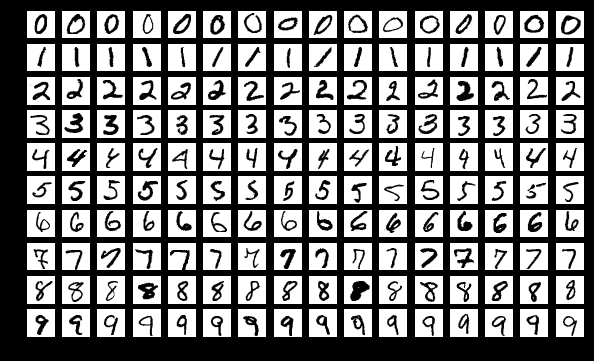

**Create a program that given an image from the mnist dataset.**
- You are free to use any algorithm you want to achieve this.
- It should be able to given a number classify what number it is.
- Accuracy should at least be 80%

If you decide to use a svm make sure you also use dimensionality reduction. SVM of the full mnist dataset will take around 4-8 hours depending on your pc.



**Challange:**
- Try to reach 98% accuracy.
- Try to classify faces with the labeled wild faces dataset [lwf](http://vis-www.cs.umass.edu/lfw/)
```{Python}
from sklearn.datasets import fetch_lfw_people
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
```

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import time
import datetime as dt
from sklearn.decomposition import PCA
from sklearn import datasets, svm, metrics
from sklearn.datasets import fetch_openml

import ssl
ssl._create_default_https_context = ssl._create_unverified_context
mnist = fetch_openml('mnist_784', version=1)

images = mnist.data.to_numpy()
targets = mnist.target.to_numpy()

print(images.shape)
print(targets.shape)

(70000, 784)
(70000,)


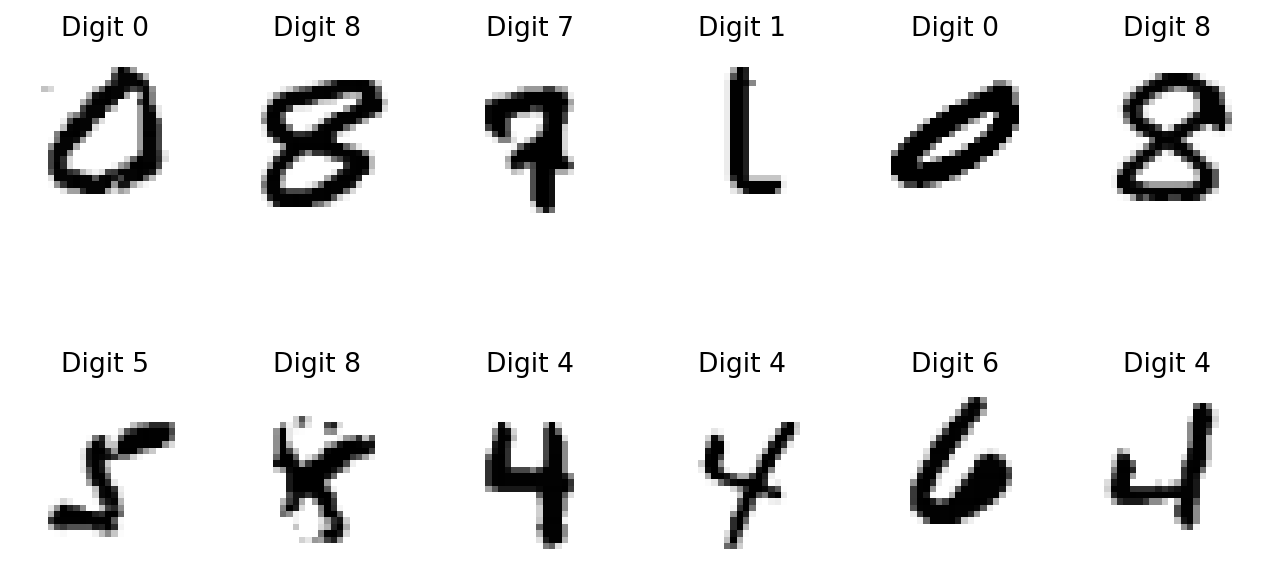

PCA components: 64 | Variance retained: 0.602
SVM+PCA Test accuracy: 0.9797
Training time: 10.51s
              precision    recall  f1-score   support

           0     0.9869    0.9929    0.9899       986
           1     0.9867    0.9911    0.9889      1125
           2     0.9829    0.9810    0.9820       999
           3     0.9745    0.9755    0.9750      1020
           4     0.9834    0.9744    0.9789       975
           5     0.9832    0.9745    0.9788       902
           6     0.9888    0.9908    0.9898       982
           7     0.9659    0.9779    0.9719      1042
           8     0.9803    0.9692    0.9747       975
           9     0.9649    0.9678    0.9663       994

    accuracy                         0.9797     10000
   macro avg     0.9798    0.9795    0.9796     10000
weighted avg     0.9797    0.9797    0.9797     10000



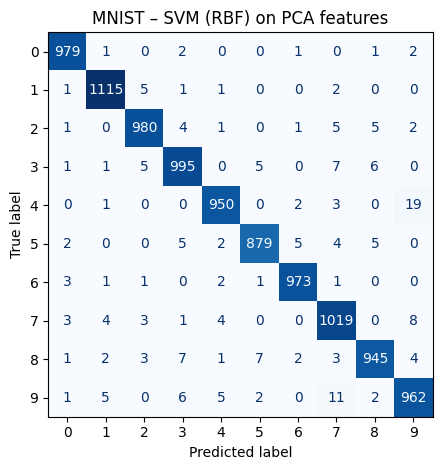

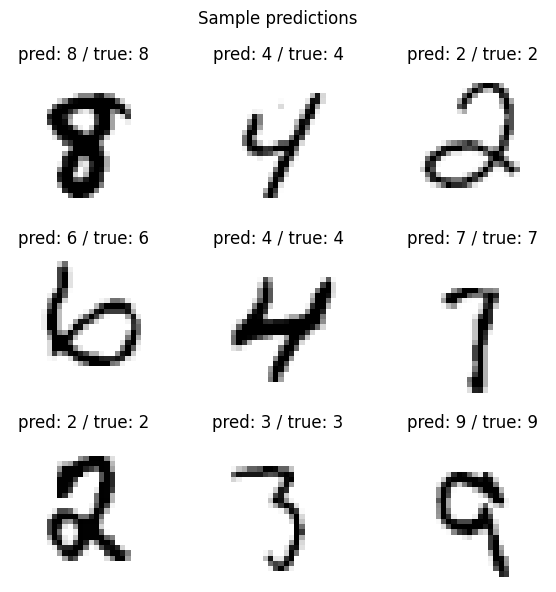

In [3]:
def show_some_digits(images, targets, sample_size=24, title_text='Digit {}' ):
    '''
    Visualize random digits in a grid plot
    images - array of flatten gidigs [:,784]
    targets - final labels
    '''
    nsamples=sample_size
    rand_idx = np.random.choice(images.shape[0], nsamples)
    images_and_labels = list(zip(images[rand_idx], targets[rand_idx]))


    img = plt.figure(1, figsize=(10, 5), dpi=160)
    for index, (image, label) in enumerate(images_and_labels):
        plt.subplot(math.ceil(nsamples/6.0), 6, index + 1)
        plt.axis('off')
        #each image is flat, we have to reshape to 2D array 28x28-784
        plt.imshow(image.reshape(28,28), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.title(title_text.format(label))
    plt.show()

# draw 12 images along with their labels
show_some_digits(images, targets, 12)

# ========= MNIST SVM + PCA pipeline =========
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm, metrics
from sklearn.metrics import ConfusionMatrixDisplay
import time

# --- 1) Prep data ---
X = images.astype("float32")            # shape: (70000, 784)
y = targets.astype(int)                 # convert labels to int

# standard 60k/10k split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)

# --- 2) Scale (very important before PCA/SVM) ---
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

# --- 3) PCA dimensionality reduction ---
# Option A: fixed number of components (fast + strong) — typically 50–80 works well
n_components = 64
# Option B (comment A out, uncomment B): keep 95% variance
# pca = PCA(n_components=0.95, svd_solver="full", random_state=0)

pca = PCA(n_components=n_components, random_state=0)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca  = pca.transform(X_test_std)

print(f"PCA components: {pca.n_components_} | "
      f"Variance retained: {pca.explained_variance_ratio_.sum():.3f}")

# --- 4) Train SVM ---
# RBF SVM works great after PCA; these defaults are strong
clf = svm.SVC(kernel="rbf", C=10.0, gamma="scale", random_state=0)

t0 = time.time()
clf.fit(X_train_pca, y_train)
t1 = time.time()

# --- 5) Evaluate ---
y_pred = clf.predict(X_test_pca)
acc = metrics.accuracy_score(y_test, y_pred)
print(f"SVM+PCA Test accuracy: {acc:.4f}")
print(f"Training time: {t1 - t0:.2f}s")

# Detailed report (optional)
print(metrics.classification_report(y_test, y_pred, digits=4))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", colorbar=False)
plt.title("MNIST – SVM (RBF) on PCA features")
plt.tight_layout()
plt.show()

# --- 6) Helper: classify a single 28x28 image (numpy array or flat 784) ---
def classify_digit(img28x28_or_flat):
    """
    Accepts:
      - 28x28 grayscale array (0-255 or 0-1), or
      - flat array of length 784
    Returns predicted digit.
    """
    x = np.asarray(img28x28_or_flat)
    if x.size == 28*28:
        x = x.reshape(1, -1)
    elif x.ndim == 2 and x.shape == (28, 28):
        x = x.reshape(1, -1)
    else:
        raise ValueError("Input must be 28x28 or flat length-784 array.")
    x_std = scaler.transform(x.astype("float32"))
    x_pca = pca.transform(x_std)
    return int(clf.predict(x_pca)[0])

# --- 7) Quick sanity-check on some test samples ---
idx = np.random.choice(len(X_test), 9, replace=False)
preds = clf.predict(X_test_pca[idx])
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for ax, i, p in zip(axes.ravel(), idx, preds):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray_r")
    ax.set_title(f"pred: {p} / true: {y_test[i]}")
    ax.axis("off")
plt.suptitle("Sample predictions")
plt.tight_layout()
plt.show()
